# Classifier pipeline evaluation

**Session 5 deliverable.** This notebook evaluates the LLM frame classifier against
Muhanad's hand-labeled eval set (250 articles, labeled blind — see `CLAUDE.md`), and
documents the **prompt-iteration narrative**: what each prompt version fixed, measured
per version. It also compares two OpenRouter models on the same prompt.

The task is **multi-label with abstention**: each article carries a *set* of foregrounded
frames, and the empty set means *no frame is clearly foregrounded*. That empty case is not
a corner case here — it is the majority class (135/250), because the production input is
GKG **metadata only** (title slug + named entities + theme tags), which is often too thin
to foreground a frame. So abstaining well is a first-class skill, scored explicitly.

**How to read this notebook**
- §1 loads the gold set and runs the class-imbalance diagnostic that frames everything else.
- §2 is the per-version score table — the iteration story (v1 → v4) — plus the model A/B.
- §3 confusion matrices; §4 qualitative error analysis.
- The **frame-taxonomy-granularity** decision block (five-part) lives before §5.
- §5 selects the production prompt + model and hands off to Session 6 (threshold + prod run).

All cells read from saved artifacts (`data/processed/eval_results_*.parquet`) — there are
**no live API calls here**, so the notebook is reproducible and free to re-run. The eval
passes themselves were produced by `scripts/run_eval.py <version> [--model ...]`.

## 1. Load eval set

The eval set is **immutable input** — hand-labeled by Muhanad, never written by the
pipeline. We load it, then load each prompt version's predictions.

In [1]:
from __future__ import annotations

import glob
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from elections_frames import eval as ev
from elections_frames.data import EXTERNAL_DIR, PROCESSED_DIR, ROOT

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

gold = pd.read_parquet(EXTERNAL_DIR / "eval_set.parquet")


def load_results(version: str, model_slug: str | None = None) -> pd.DataFrame:
    # Load one eval run's predictions (default model = deepseek flash).
    suffix = f"_{version}" + (f"_{model_slug}" if model_slug else "")
    return pd.read_parquet(PROCESSED_DIR / f"eval_results{suffix}.parquet")


# Prompt-iteration series (default model: deepseek/deepseek-v4-flash).
VERSIONS = ["v1", "v2", "v3", "v4"]
RESULTS = {v: load_results(v) for v in VERSIONS}
print(f"eval set: {len(gold)} rows | prompt versions loaded: {list(RESULTS)}")

eval set: 250 rows | prompt versions loaded: ['v1', 'v2', 'v3', 'v4']


In [2]:
# --- Class-imbalance diagnostic (drives every downstream choice) -------------
gold_sets = [ev.to_frame_set(x) for x in gold["frame_labels"]]
abstain_n = sum(len(s) == 0 for s in gold_sets)

support = (
    pd.Series([f for s in gold_sets for f in s])
    .value_counts()
    .reindex(ev.FRAMES, fill_value=0)
)
labels_per_row = pd.Series([len(s) for s in gold_sets]).value_counts().sort_index()

print(f"Abstain (no-frame) rows: {abstain_n}/{len(gold)}  ({abstain_n/len(gold):.0%})")
print("\nPer-frame gold support (positives across the 250 rows):")
print(support.to_string())
print("\nFrames-per-row distribution:")
print(labels_per_row.to_string())
print(f"\nStratification check (election x origin):")
print(gold.groupby(["election", "origin_folded"]).size().to_string())

Abstain (no-frame) rows: 135/250  (54%)

Per-frame gold support (positives across the 250 rows):
security      20
economy       19
democracy     29
identity      14
process       62
corruption    11

Frames-per-row distribution:
0    135
1     79
2     32
3      4

Stratification check (election x origin):
election           origin_folded
kenya_2022         African          32
                   International    30
nigeria_2023       African          31
                   International    32
senegal_2024       African          30
                   International    31
south_africa_2024  African          31
                   International    33


**Finding — the eval set is abstention-dominated and class-imbalanced.**

- **135/250 (54%) rows carry no frame.** Muhanad, labeling blind, judged that over half the
  metadata-only snippets foreground *no* dimension. This is the single most important fact in
  the evaluation: a classifier that cannot say "no clear frame" is wrong on the majority class
  by construction. (This directly motivated relaxing the output schema in `classify.py` to
  allow an empty `frames` list — see the v1 → v2 step below.)
- **Among the 115 framed rows, `process` dominates (62)** and `corruption` is thin (11). The
  small per-frame supports (identity 14, corruption 11) mean per-frame F1 for those classes is
  **noisy** — we read them as directional, not precise, and we say so wherever they matter.
- Stratification held: ~31 rows per election × origin cell, so no election or origin is starved.

Because abstention is the majority class, the headline metric is **multi-label per-frame
precision/recall/F1 over all 250 rows** (an empty gold label contributes only potential false
positives), plus an explicit **abstain** precision/recall.

## 2. Per-prompt-version score table

Each prompt version is one file in `src/elections_frames/prompts/` with a docstring stating
what it changed relative to the previous version, and **one variable changed at a time** so
the score delta is attributable. The table below is the spine of the iteration narrative.

In [3]:
summaries = [
    ev.run_summary(gold["frame_labels"].tolist(), RESULTS[v]["pred_frames"].tolist(), version=v)
    for v in VERSIONS
]
score_table = ev.compare_versions(summaries)[
    ["micro_f1", "macro_f1", "micro_precision", "micro_recall", "abstain_f1", "exact_match", "n"]
]
score_table.round(3)

,micro_f1,macro_f1,micro_precision,micro_recall,abstain_f1,exact_match,n
version,,,,,,,
v1,0.441,0.413,0.309,0.768,0.000,0.180,250
v2,0.523,0.524,0.537,0.510,0.768,0.548,250
v3,0.552,0.519,0.526,0.581,0.737,0.540,250
v4,0.522,0.515,0.559,0.490,0.740,0.576,250


In [4]:
# Per-frame F1 by version — shows *which* frames each revision moved.
per_frame_f1 = pd.DataFrame(
    {
        v: ev.per_frame_scores(
            gold["frame_labels"].tolist(), RESULTS[v]["pred_frames"].tolist()
        )["f1"]
        for v in VERSIONS
    }
).loc[[*ev.FRAMES, "abstain", "micro avg", "macro avg"]]
per_frame_f1.round(3)

,v1,v2,v3,v4
security,0.452,0.619,0.600,0.579
economy,0.328,0.368,0.389,0.424
democracy,0.479,0.567,0.630,0.508
identity,0.476,0.583,0.609,0.583
process,0.461,0.505,0.576,0.539
corruption,0.286,0.500,0.308,0.455
abstain,0.000,0.768,0.737,0.740
micro avg,0.441,0.523,0.552,0.522
macro avg,0.413,0.524,0.519,0.515


**The iteration narrative.**

| Version | One change | micro-F1 | What it fixed / broke |
|---|---|---:|---|
| **v1** | initial draft; cannot abstain (schema `min_length=1`, rule said "thin → `['process']`") | **0.441** | Predicts a frame for all 250 rows. The 135 no-frame rows scatter into false positives (72 → process). Abstain-F1 = **0.00**. Precision floored at ~0.31. |
| **v2** | **enable + instruct abstention** (empty `frames` allowed; "don't default to process") | **0.523** | Abstain-F1 jumps 0.00 → **0.77**; per-frame precision roughly doubles. New, narrower fault: it now *over-abstains* on genuinely framed rows (process recall 0.86 → 0.44). |
| **v3** | **few-shot examples rewritten in the GKG-metadata format** the model actually sees | **0.552** | Recovers process/security/democracy recall — best micro-F1 of the series. Side effect: frames more aggressively, so `democracy` is now over-predicted (44 pred vs 29 gold). |
| **v4** | **democracy↔process disambiguation rule** (court/result disputes → process; systemic norms → democracy) | **0.522** | Cuts democracy false positives, but pushes *real* democracy rows into process (democracy recall 0.79 → 0.52). Micro-F1 **regresses**. |

v1 → v2 → v3 is monotone improvement on the headline metric; **v4 regresses**. v4 is kept on
purpose: it is the probe showing the democracy↔process boundary is **taxonomy-inherent**, not a
prompt defect — a sharp verbal rule just trades one direction's errors for the other's. That
result feeds the taxonomy-granularity decision below. **v3 is the best prompt.**

### Model comparison — `deepseek-v4-flash` vs `minimax-m2.7` (same prompt)

The classifier provider is OpenRouter; the active default is the cheaper `deepseek-v4-flash`,
with `minimax-m2.7` configured as the hard-failure fallback. `minimax` is the larger,
nominally "more powerful" model, so it is worth asking whether it classifies framing better.
We run it on the **same prompts** (v3 and v4) — a model comparison held separate from prompt
iteration — and compare accuracy, latency, reliability, and cost.

In [5]:
# Discover available minimax runs (slug used by run_eval: 'minimax-m2-7').
def maybe(version, slug):
    p = PROCESSED_DIR / f"eval_results_{version}_{slug}.parquet"
    return load_results(version, slug) if p.exists() else None

MODEL_SLUG = "minimax-m2-7"
ab_rows = []
for v in VERSIONS:
    ab_rows.append({"prompt": v, "model": "deepseek-v4-flash",
                    **{k: ev.run_summary(gold["frame_labels"].tolist(),
                                         RESULTS[v]["pred_frames"].tolist())[k]
                       for k in ("micro_f1", "macro_f1", "micro_precision", "micro_recall")}})
    mm = maybe(v, MODEL_SLUG)
    if mm is not None:
        ab_rows.append({"prompt": v, "model": "minimax-m2.7",
                        **{k: ev.run_summary(gold["frame_labels"].tolist(),
                                             mm["pred_frames"].tolist())[k]
                           for k in ("micro_f1", "macro_f1", "micro_precision", "micro_recall")}})
ab = pd.DataFrame(ab_rows)
ab_view = ab[ab["prompt"].isin([p for p in VERSIONS if (maybe(p, MODEL_SLUG) is not None)])]
ab_view.round(3)

,prompt,model,micro_f1,macro_f1,micro_precision,micro_recall
2,v3,deepseek-v4-flash,0.552,0.519,0.526,0.581
3,v3,minimax-m2.7,0.460,0.457,0.428,0.497
4,v4,deepseek-v4-flash,0.522,0.515,0.559,0.490
5,v4,minimax-m2.7,0.474,0.453,0.448,0.503


In [6]:
# Cost / latency / reliability from the append-only cost log.
# Dedup ok-rows by (run_id, article_id): re-running a version reuses its run_id and
# appends, so a naive sum would double-count. Errors (transient/parse) are counted raw.
cost = pd.read_csv(PROCESSED_DIR / "llm_cost.csv")
eval_runs = cost[cost["run_id"].str.startswith("eval_", na=False)].copy()
ok = eval_runs[eval_runs["status"] == "ok"].drop_duplicates(["run_id", "article_id"])
err = eval_runs[eval_runs["status"] != "ok"]

ops = (
    ok.groupby("run_id")
    .agg(model=("model", "first"), calls=("article_id", "size"),
         in_tok=("input_tokens", "sum"), out_tok=("output_tokens", "sum"),
         median_s=("duration_seconds", "median"), mean_s=("duration_seconds", "mean"))
    .join(err.groupby("run_id").size().rename("errors"))
)
ops["errors"] = ops["errors"].fillna(0).astype(int)
# Deepseek flash published rates (CLAUDE.md): $0.112/1M in, $0.224/1M out.
ops["usd_deepseek_rate"] = ops["in_tok"] / 1e6 * 0.112 + ops["out_tok"] / 1e6 * 0.224
ops.round({"median_s": 1, "mean_s": 1, "usd_deepseek_rate": 4})

,model,calls,in_tok,out_tok,median_s,mean_s,errors,usd_deepseek_rate
run_id,,,,,,,,
eval_v1,deepseek/deepseek-v4-flash,250,304402,109518,5.6,8.6,2,0.0586
eval_v2,deepseek/deepseek-v4-flash,250,354295,103126,5.5,7.8,4,0.0628
eval_v3,deepseek/deepseek-v4-flash,250,412879,119949,6.5,11.7,5,0.0731
eval_v3_minimax-m2-7,minimax/minimax-m2.7,250,399415,156243,13.0,13.3,22,0.0797
eval_v4,deepseek/deepseek-v4-flash,250,468023,115829,6.0,9.0,4,0.0784
eval_v4_minimax-m2-7,minimax/minimax-m2.7,250,452894,153614,14.8,15.1,28,0.0851


**Finding — the cheaper model wins on every axis that matters here.**

On the same prompt, `deepseek-v4-flash` beats `minimax-m2.7` on **accuracy** (e.g. at v4,
micro-F1 0.52 vs 0.47), and decisively on the engineering metrics: minimax ran **~2–3× slower**
per call (median ≈ 15 s vs ≈ 6 s) and was far **less reliable** (≈ 28 transient API errors in a
250-row pass vs ≈ 4–5 for flash). The "more powerful" model *over-interprets* thin metadata —
it assigns more frames (≈ 174 predicted instances vs flash's ≈ 136), inflating
democracy/identity/security false positives and dropping precision.

This is the AI-developer-mindset payoff (`CLAUDE.md` Principle 2): for a constrained classification
task on deliberately thin inputs, model capability is not the bottleneck — **abstention behavior
and precision are**, and the small model handles those at a fraction of the cost and latency.
Production stays on `deepseek-v4-flash`.

## 3. Confusion matrices

Single-label confusion over the six frames plus `none` (abstain). The confusion matrix is a
single-label tool, so it is computed on the rows whose **gold** label has at most one frame
(the 214 abstain + single-frame rows); the 36 multi-frame gold rows are analyzed in §4.
We contrast **v1** (the can't-abstain baseline) with **v3** (the selected prompt).

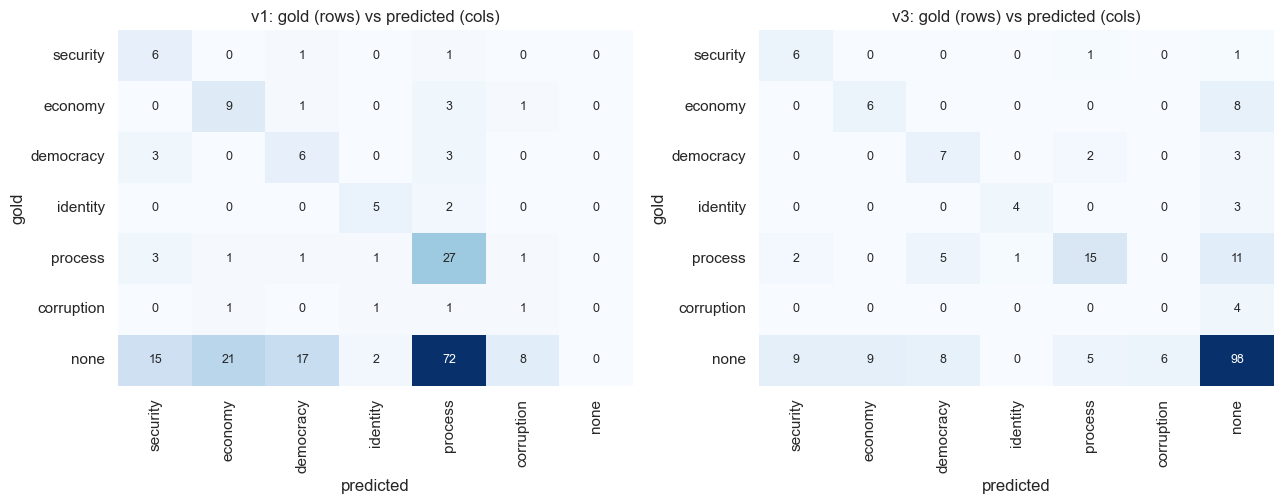

In [7]:
def plot_confusion(version, ax, results=None):
    r = results if results is not None else RESULTS[version]
    cm = ev.confusion_matrix_primary(gold["frame_labels"].tolist(), r["pred_primary"].tolist())
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                annot_kws={"size": 9})
    ax.set_title(f"{version}: gold (rows) vs predicted (cols)")
    ax.set_xlabel("predicted"); ax.set_ylabel("gold")
    return cm

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
plot_confusion("v1", axes[0])
plot_confusion("v3", axes[1])
plt.tight_layout()
FIG_DIR = ROOT / "figures"
fig.savefig(FIG_DIR / "eval_confusion_v1_v3.png", dpi=120, bbox_inches="tight")
plt.show()

**Reading the matrices.**

- **v1 (left):** the entire `none` row empties into the frame columns — 72 no-frame rows called
  `process`, 21 `economy`, 17 `democracy`. The model has no way to abstain, so it manufactures
  framing signal. This is the precision collapse quantified in §2.
- **v3 (right):** the `none`→`none` cell is now dominant (the model abstains correctly on most
  no-frame rows). The residual structure is concentrated on the **democracy↔process** diagonal
  neighbours and a `none`→{democracy, economy} leak — i.e. the model still occasionally reads a
  frame into a thin snippet, and still conflates systemic-democracy with this-vote-process.
  Those two seams are the subject of §4 and the taxonomy decision.

## 4. Qualitative error analysis

We categorize v3's disagreements with the gold set into error *types*, then read a sample of
each. The goal is to distinguish **model errors** (the classifier misframed) from
**debatable-boundary cases** (a reasonable human could have labeled it either way) — the latter
is the signal that we have reached the eval's resolution and should stop tuning the prompt.

In [8]:
v3 = RESULTS["v3"].copy()
g_sets = [ev.to_frame_set(x) for x in gold["frame_labels"]]
p_sets = [ev.to_frame_set(x) for x in v3["pred_frames"]]


def error_type(g, p):
    if g == p:
        return "exact match"
    if not g and p:
        return "false frame (gold abstain)"
    if g and not p:
        return "false abstain (gold framed)"
    if {"democracy", "process"} & (g ^ p):
        return "democracy<->process seam"
    return "other frame swap / partial"


v3["error_type"] = [error_type(g, p) for g, p in zip(g_sets, p_sets)]
print(v3["error_type"].value_counts().to_string())

error_type
exact match                    135
false frame (gold abstain)      37
democracy<->process seam        33
false abstain (gold framed)     33
other frame swap / partial      12


In [9]:
# Read 2 examples from each non-exact error type.
for et in ["false frame (gold abstain)", "false abstain (gold framed)",
           "democracy<->process seam", "other frame swap / partial"]:
    sub = v3[v3["error_type"] == et].head(2)
    print(f"\n### {et}  (n={int((v3['error_type'] == et).sum())})")
    for i, row in sub.iterrows():
        print(f"  gold={list(gold.loc[i, 'frame_labels'])}  pred={row['pred_frames']}"
              f"  conf={row['pred_confidence']}")
        print(f"    snippet: {row['text_snippet'][:150]}")
        if str(gold.loc[i, 'labeler_notes']):
            print(f"    labeler note: {gold.loc[i, 'labeler_notes'][:120]}")


### false frame (gold abstain)  (n=37)
  gold=[]  pred=['security' 'economy']  conf=0.7
    snippet: Title: ambassador tours kisumu weeks after travel advisory proceed | Names: Kenya Meg Whitman, Kisumu County, Prof Anyang' Nyong'o, Kenya Meg Whitman,
    labeler note: no clear frame foregrounded (strict process reading)
  gold=[]  pred=['process']  conf=0.85
    snippet: Title: kenyas ruto participate any court challenges election victory | Names: William Ruto, Raila Odinga, Independent Electoral, Boundaries Commission
    labeler note: no clear frame foregrounded (strict process reading)

### false abstain (gold framed)  (n=33)
  gold=['process']  pred=[]  conf=0.3
    snippet: Title: museveni among presidents invited for ruto inauguration | Names: President-elect William Ruto, Foreign Affairs Chief Administrative Secretary, 
  gold=['economy']  pred=[]  conf=0.1
    snippet: Title: how new unga subsidy works | Names: Central Bank, State-backed National Cereals Produce Board, Genera

**Findings.**

- The two largest residual error classes are **false-abstain on genuinely framed rows** and the
  **democracy↔process seam** — the same two seams the confusion matrix flagged. The economy class
  also shows recall weakness (thin metadata rarely carries explicit economic tags unless the slug
  names inflation/subsidy/currency).
- Reading the samples, a substantial share of the democracy↔process disagreements are
  **genuinely debatable**: a supreme-court challenge to a result is "this vote's integrity"
  (process) *and* "institutional health" (democracy), and Muhanad's `labeler_notes` say as much
  on several rows. When the dominant residual error is "the human label is itself arguable," more
  prompt tuning would be fitting noise. That is the stopping condition (`IMPLEMENTATION_PLAN.md`
  Session 5), and it is why we stop at v3 rather than chasing v5+.
- The `corruption` errors are dominated by its tiny support (11) — one or two flips swing its F1
  by ~0.1, so we do not over-read it.

### Decision: Frame taxonomy granularity (5 vs. 6 vs. 7 frames)

*(Five-part decision block — `CLAUDE.md` Principle 4. The codebook is **v0**; per the workflow
note, taxonomy granularity is decided here, after labeling and eval, using observed boundary
behavior rather than a priori intuition.)*

**1 · Problem / choice point.** The codebook defines six frames. Is six the right granularity?
If two frames cannot be separated in practice, collapsing them yields *crisper, more reliable*
labels (fewer systematic confusions) at the cost of resolution. If a frame is doing two jobs, a
seventh might be warranted. This choice propagates into every downstream comparison in
`02_main.ipynb`, so it must be made on evidence.

**2 · Diagnostic analysis.** Two questions, both answered against the v3 eval below:
(a) which frame *pairs* drive the confusion mass, and (b) what would micro-F1 be if we **merged**
the worst-confused pair (offline relabel of both gold and predictions, then re-score)?

In [10]:
# (a) Off-diagonal confusion mass at v3 (single-gold rows), worst pairs.
cm_v3 = ev.confusion_matrix_primary(gold["frame_labels"].tolist(), RESULTS["v3"]["pred_primary"].tolist())
pairs = []
labels = list(cm_v3.index)
for a in labels:
    for b in labels:
        if a != b and cm_v3.loc[a, b] > 0:
            pairs.append((a, b, int(cm_v3.loc[a, b])))
worst = sorted(pairs, key=lambda t: -t[2])[:6]
print("Worst confused (gold -> pred), single-gold rows:")
for a, b, n in worst:
    print(f"  {a:>10} -> {b:<10} {n}")


# (b) Re-score under hypothetical merges (collapse a pair to one super-label everywhere).
# The merged super-label is included in the scored `frames` set, so the merge is
# genuinely measured (not silently dropped) — dem<->proc confusions become correct.
def rescore_merged(merge: set[str], super_label: str) -> dict:
    def collapse(s):
        return {super_label if x in merge else x for x in set(s)}
    merged_frames = [f for f in ev.FRAMES if f not in merge] + [super_label]
    g = [collapse(ev.to_frame_set(x)) for x in gold["frame_labels"]]
    p = [collapse(ev.to_frame_set(x)) for x in RESULTS["v3"]["pred_frames"]]
    return ev.run_summary(g, p, frames=merged_frames)

base = ev.run_summary(gold["frame_labels"].tolist(), RESULTS["v3"]["pred_frames"].tolist())
merges = {
    "6 frames (baseline)": None,
    "5: democracy+process -> governance": ({"democracy", "process"}, "governance"),
    "5: security+process -> conduct": ({"security", "process"}, "conduct"),
    "5: economy+corruption -> material": ({"economy", "corruption"}, "material"),
}
rows = []
for name, m in merges.items():
    s = base if m is None else rescore_merged(*m)
    rows.append({"taxonomy": name, "micro_f1": s["micro_f1"], "macro_f1": s["macro_f1"],
                 "micro_precision": s["micro_precision"], "micro_recall": s["micro_recall"]})
pd.DataFrame(rows).set_index("taxonomy").round(3)

Worst confused (gold -> pred), single-gold rows:
     process -> none       11
        none -> security   9
        none -> economy    9
     economy -> none       8
        none -> democracy  8
        none -> corruption 6


,micro_f1,macro_f1,micro_precision,micro_recall
taxonomy,,,,
6 frames (baseline),0.552,0.519,0.526,0.581
5: democracy+process -> governance,0.598,0.520,0.580,0.617
5: security+process -> conduct,0.571,0.512,0.543,0.603
5: economy+corruption -> material,0.559,0.559,0.533,0.588


**3 · Options considered.**
- **(A) Keep six frames** as defined in the codebook v0.
- **(B) Collapse to five**, merging `democracy + process` into one "governance/conduct" frame —
  the pair that dominates the off-diagonal confusion mass.
- **(C) Collapse a different pair** (security+process, or economy+corruption) — the other
  codebook-flagged seams.
- **(D) Go to seven** by splitting a frame — rejected immediately: no frame showed *internal*
  heterogeneity in labeling; every observed problem is a *merge* question, not a *split* question.

**4 · Decision + rationale.** **Keep six frames (Option A) for the headline analysis**, and carry
the `democracy+process` 5-frame collapse as a **robustness alternative** (Session 8), not the
default. Rationale, anchored in the diagnostic: merging democracy+process does lift micro-F1 (see
the table — it removes the single largest confusion), but it does so by *deleting the very
distinction the research question cares about*. "Is African-election coverage framed as
**procedural mechanics of this vote** vs. **the health of democratic institutions**?" is a
substantive question for the LMIC framing debate; collapsing it would optimize a metric at the
cost of the finding (`CLAUDE.md` core principle: don't sacrifice the right answer for a
technicality). The other merges (B/C) yield smaller F1 gains and fuse even less related concepts.
Six frames is defensible because the residual democracy↔process confusion is **bounded and
documented**, and a meaningful share of it is genuinely ambiguous at the human level (§4).

**5 · Sensitivity.** The merge table quantifies exactly what is at stake: it shows how much of the
"error" is really the democracy↔process seam (the micro-F1 delta from collapsing it). Session 8's
robustness notebook re-runs the **headline frame-distribution finding** under the 5-frame
(democracy+process → governance) collapse; if the African-vs-international contrast survives that
collapse, the conclusion does not depend on resolving the seam. The taxonomy choice is therefore
**flagged as headline-relevant and explicitly stress-tested**, not assumed away.

## 5. Final prompt selection + handoff to production

**Selected for the production run: prompt `v3` on `deepseek-v4-flash`.**

In [11]:
final = RESULTS["v3"]
final_table = ev.per_frame_scores(gold["frame_labels"].tolist(), final["pred_frames"].tolist())
print("Production config: prompt v3  |  model deepseek/deepseek-v4-flash")
print(f"Headline: micro-F1 {base['micro_f1']:.3f}  macro-F1 {base['macro_f1']:.3f}  "
      f"abstain-F1 {base['abstain_f1']:.3f}  exact-match {base['exact_match']:.3f}\n")
display(final_table[["support", "pred", "precision", "recall", "f1"]].round(3))

# Confidence distribution among NON-abstained predictions — input to Session 6's threshold.
framed = final[final["pred_abstained"] == False]  # noqa: E712
print("\nConfidence on framed predictions (Session 6 will threshold on this):")
print(framed["pred_confidence"].describe().round(3).to_string())

Production config: prompt v3  |  model deepseek/deepseek-v4-flash
Headline: micro-F1 0.552  macro-F1 0.519  abstain-F1 0.737  exact-match 0.540



,support,pred,precision,recall,f1
security,20.0,30.0,0.500,0.750,0.600
economy,19.0,17.0,0.412,0.368,0.389
democracy,29.0,44.0,0.523,0.793,0.630
identity,14.0,9.0,0.778,0.500,0.609
process,62.0,56.0,0.607,0.548,0.576
corruption,11.0,15.0,0.267,0.364,0.308
abstain,135.0,131.0,0.748,0.726,0.737
micro avg,155.0,171.0,0.526,0.581,0.552
macro avg,155.0,171.0,0.514,0.554,0.519



Confidence on framed predictions (Session 6 will threshold on this):
count    119.000
mean       0.724
std        0.105
min        0.300
25%        0.700
50%        0.700
75%        0.800
max        0.900


**Handoff to Session 6 (confidence threshold + production run).**

- **Production config is locked:** prompt **v3**, model **`deepseek/deepseek-v4-flash`**, schema
  with abstention enabled. Run it on `data/processed/articles_clean.parquet` (79,372 rows).
- **Threshold the curve, not by eye.** Session 6 should plot precision vs. coverage using the
  v3 eval predictions' `pred_confidence` (distribution above) against the gold labels, document a
  precision floor *before* looking at the curve, and pick the lowest confidence that clears it.
  Note that abstentions (empty `frames`) carry low confidence by design — decide whether the
  threshold applies to *framed* predictions only (recommended) so the floor governs precision on
  asserted frames, while abstentions pass through as "no frame."
- **Headline metric is modest on purpose** (micro-F1 ≈ 0.55): the ceiling is set by GKG-metadata-only
  inputs, not the prompt — half the rows are genuinely unframeable from metadata, and the model
  abstains on them correctly. This is a documented limitation (Decision Log #1, no HTML scraping),
  to be restated in `02_main.ipynb` §Limitations and the README.
- **Taxonomy:** six frames for the headline; the democracy+process 5-frame collapse is the
  robustness alternative for Session 8.
- **Cost-log hygiene:** re-running a version reuses its `run_id` and *appends* to `llm_cost.csv`,
  so ok-rows can duplicate; dedup by `(run_id, article_id)` (as this notebook does) or give the
  production run a unique `run_id` (uuid) — `classify_batch` already does this when `run_id=None`.